In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import hist

from models import carl, rolypoly
from physics.simulation import mcfm, msq
from physics.hzz import zz4l, zpair
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [2]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

CARL_JOB = 'qqZZ-vs-SBI-05'
CARL_CKPT = [58,0.68]
ROLYPOLY_JOB = 'refactor-eight-SBI-3M'
ROLYPOLY_CKPT = [[178,0.05],['06',0.15],[83,0.01],[187,0.03]]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'
SAMPLE_FILE_qqZZ = 'qqZZ2e2m.csv'

CARL_PATH = os.path.join(JOB_DIR, 'carl', CARL_JOB)
CARL_CKPT_PATH = os.path.join(CARL_PATH, 'checkpoints', f'checkpoint-carl-epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
ROLYPOLY_PATH = os.path.join(JOB_DIR, 'rolypoly', ROLYPOLY_JOB)
ROLYPOLY_CKPT_PATHs = [os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-rolypoly-epoch={ROLYPOLY_CKPT[i][0]}-val_loss={ROLYPOLY_CKPT[i][1]}.ckpt') for i in range(len(ROLYPOLY_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
SAMPLE_PATH_qqZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_qqZZ)

In [124]:
SAMPLE_SIZE = 1000000

luminosity = 3000

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 512

C6_LINSPACE = [-23,23,415]

C6_VAL_DATA = 0

SEED = 42

In [4]:
xs = {'ggZZ': 1.5569109*4, 'qqZZ': 14.482054*4}

In [5]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_qqZZ, n_rows=SAMPLE_SIZE*1.2)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()
fourlep = zz4l.FourLeptonSystem()
m4l_filter = zz4l.M4l(0,np.inf)

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

6.415952601856002
63.06121033201865


In [125]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
c6_weights, c6_prob = c6_mod.modify(c6=np.linspace(*C6_LINSPACE))#C6_VAL_DATA)

In [126]:
c6_index = np.where(np.linspace(*C6_LINSPACE)==C6_VAL_DATA)[0][0]
c6_zero_index = np.where(np.linspace(*C6_LINSPACE)==0.0)[0][0]

In [127]:
true_probs = np.array([np.concatenate([c6_weights[:SAMPLE_SIZE//2,i], events_qqZZ_processed[:SAMPLE_SIZE//2].weights]) for i in range(c6_weights.shape[1])])
true_probs /= np.sum(true_probs, axis=1)[:, np.newaxis]

In [128]:
# ggZZ + qqZZ

events_final = mcfm.Process(pd.concat([events_ggZZ_processed.kinematics[:SAMPLE_SIZE//2], events_qqZZ_processed.kinematics[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
                            pd.concat([events_ggZZ_processed.components[:SAMPLE_SIZE//2], events_qqZZ_processed.components[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
                            pd.concat([pd.Series(c6_weights[:,c6_index].flatten()).reset_index(drop=True)[:SAMPLE_SIZE//2]*np.sum(c6_weights[:,c6_index])/np.sum(c6_weights[:SAMPLE_SIZE//2, c6_index]), events_qqZZ_processed.weights[:SAMPLE_SIZE//2].reset_index(drop=True)*sigma_qqZZ/events_qqZZ_processed.weights[:SAMPLE_SIZE//2].sum()],ignore_index=True).reset_index(drop=True))

In [10]:
# This is for ggZZ only

#events_final = mcfm.Process(events_ggZZ_processed.kinematics.reset_index(drop=True)[:SAMPLE_SIZE],
#                            events_ggZZ_processed.components.reset_index(drop=True)[:SAMPLE_SIZE],
#                            pd.Series(c6_weights[:,c6_index].flatten()).reset_index(drop=True)[:SAMPLE_SIZE]*np.sum(c6_weights[:,c6_index])/np.sum(c6_weights[:SAMPLE_SIZE,c6_index]))
                        #   Fixing the cross section to remain the same after cutting events to SAMPLE_SIZE

In [129]:
sigma_data = events_final.weights.sum()

In [12]:
kinematics = events_final.kinematics[FEATURES]

In [13]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [14]:
models_rolypoly = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=path) for path in ROLYPOLY_CKPT_PATHs]

In [15]:
with open(os.path.join(CARL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)

X_carl = scaler_carl.transform(kinematics.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [16]:
m4l = events_final.kinematics[['4l_mass']].to_numpy().flatten()
indices = np.arange(len(m4l))
probabilities = np.concatenate([events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy(), events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy()], axis=0)

bins = 60
bounds = [180,1000]
step_size = (bounds[1]-bounds[0])/bins

labels = np.concatenate([np.zeros(SAMPLE_SIZE//2), np.ones(SAMPLE_SIZE//2)], axis=0)

prob_binned = [probabilities[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]
labels_binned = [labels[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]
indices_binned = [indices[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]

sig_sum = np.array([np.sum(prob_binned[i][labels_binned[i]==1.0]) for i in range(bins)])
bkg_sum = np.array([np.sum(prob_binned[i][labels_binned[i]==0.0]) for i in range(bins)])

ratios_binned = sig_sum/bkg_sum

r_histo = np.zeros(len(m4l))
for i in range(bins):
    for ind in indices_binned[i]:
        r_histo[ind] = ratios_binned[i]

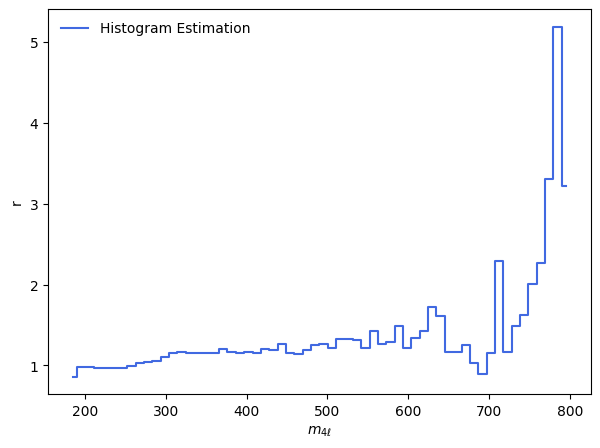

In [17]:
bins = 60

bounds = [180,800]
step_size = (bounds[1]-bounds[0])/bins

#r_binned = [np.mean(r[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))]) for i in range(bins)]
#r_binned_std = [np.std(r[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))]) for i in range(bins)]

centers = [step_size * (i + 1/2) + bounds[0] for i in range(bins)]

fig = plt.figure(figsize=(7,5))

#plt.errorbar(centers, r_binned, yerr=r_binned_std, drawstyle='steps-mid', color='red', label='CARL')
plt.errorbar(centers, ratios_binned, linestyle='-', drawstyle='steps-mid', color='royalblue', label='Histogram Estimation')

plt.ylabel('r')
plt.xlabel('$m_{4\ell}$')

plt.legend(frameon=False)

plt.show()

In [18]:
trainer = L.Trainer(accelerator='cpu')

pred_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1954/1954 [07:06<00:00,  4.58it/s]


In [19]:
r = pred_carl/(1-pred_carl)


##### CARL calibration 

In [20]:
ggZZ_wt_SM = events_ggZZ_processed[:SAMPLE_SIZE//2].weights.to_numpy() * sigma_ggZZ/events_ggZZ_processed[:SAMPLE_SIZE//2].weights.sum()

R = 1/sigma_ggZZ * np.sum(ggZZ_wt_SM * r[:SAMPLE_SIZE//2])

r /= R

In [21]:
cut_inds = np.where((np.log(r) >= -0.5)&(np.log(r) < 0.7))

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_1362636/4138961199.py:20: RuntimeWarning: divide by zero encountered in divide
  truth_ratios = np.log(sig_per_bin/bkg_per_bin)
/tmp/ipykernel_1362636/4138961199.py:20: RuntimeWarning: invalid value encountered in divide
  truth_ratios = np.log(sig_per_bin/bkg_per_bin)
/tmp/ipykernel_1362636/4138961199.py:20: RuntimeWarning: divide

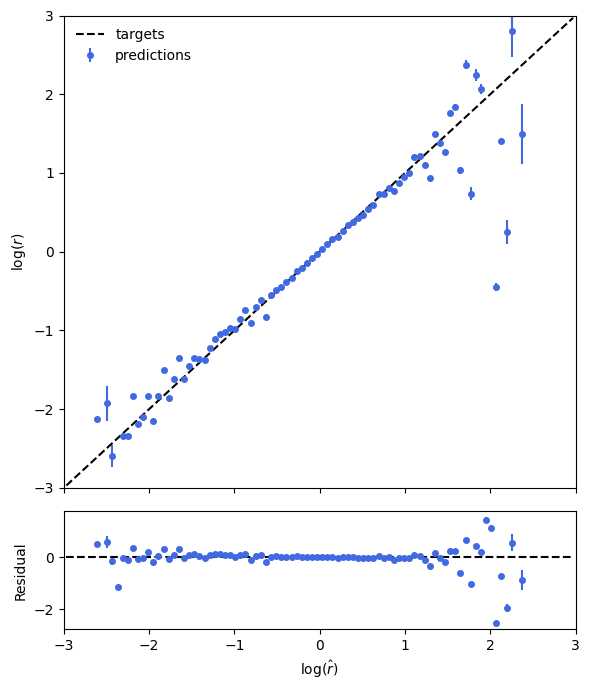

In [22]:
bins = 100
bounds = [-3,3]
step_size = (bounds[1]-bounds[0])/bins

weights = np.concatenate([events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy(), events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy()], axis=0)

p = np.log(r)
t = np.concatenate([np.zeros(len(r)//2), np.ones(len(r)//2)], axis=0)

pred_binned = [p[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]
targets_binned = [t[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]
weights_binned = [weights[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

sig_per_bin = np.array([np.sum(weights_binned[i][targets_binned[i]==1.0]) for i in range(bins)])
bkg_per_bin = np.array([np.sum(weights_binned[i][targets_binned[i]==0.0]) for i in range(bins)])

sig_dev = np.array([np.std(weights_binned[i][targets_binned[i]==1.0]) for i in range(bins)])
bkg_dev = np.array([np.std(weights_binned[i][targets_binned[i]==0.0]) for i in range(bins)])

truth_ratios = np.log(sig_per_bin/bkg_per_bin)
truth_ratios_dev = np.sqrt(( sig_dev/sig_per_bin )**2 + ( bkg_dev/bkg_per_bin )**2)

pred_ratios_avg = [np.mean(pred_binned[i]) for i in range(bins)]

centers = [bounds[0]+(i+1/2)*step_size for i in range(bins)]

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4,1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, centers, color='black', linestyle='--', label='targets')
ax1.errorbar(centers, truth_ratios, yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$\log(r)$')

ax1.legend(frameon=False)

ax2.errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', label='targets')
ax2.errorbar(centers, np.array(truth_ratios)-np.array(centers), yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$\log(\hat{r})$')
ax2.set_ylabel('Residual')

plt.tight_layout()
plt.show()

In [23]:
dls_rolypoly = []
for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_rolypoly = scaler_X.transform(kinematics.to_numpy())
    dl = DataLoader(TensorDataset(torch.tensor(X_rolypoly, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)
    dls_rolypoly.append(dl)

In [24]:
coeffs_pred = []

for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_rolypoly[i], dls_rolypoly[i])).numpy()[:,np.newaxis]).flatten())

coeffs_pred = np.array(coeffs_pred).T

Predicting DataLoader 0: 100%|██████████| 1954/1954 [03:43<00:00,  8.76it/s]


In [25]:
coeffs_true = c6_mod.coefficients[:SAMPLE_SIZE,1:]

In [26]:
def histplot_RP(coeff_ind, ax, color, label, bounds, bins, coeffs, weights):
    h = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h.fill(coeffs[:,coeff_ind], weight=weights)

    h.plot(ax=ax, color=color, label=label)

def compare_hists_RP(coeff_index, ax, coeffs, weights, bounds, bins=60, colors=['royalblue', 'red'], labels=['ggZZ', 'qqZZ']):
    histplot_RP(coeff_index, ax, colors[0], labels[0], bounds, bins, coeffs[0], weights[0])
    histplot_RP(coeff_index, ax, colors[1], labels[1], bounds, bins, coeffs[1], weights[1])

    ax.set_xlim(*bounds)
    ax.legend(frameon=False)
    ax.set_xlabel(f'coeff {coeff_index+1}')
    ax.set_ylabel('probability')
    ax.set_yscale('log')

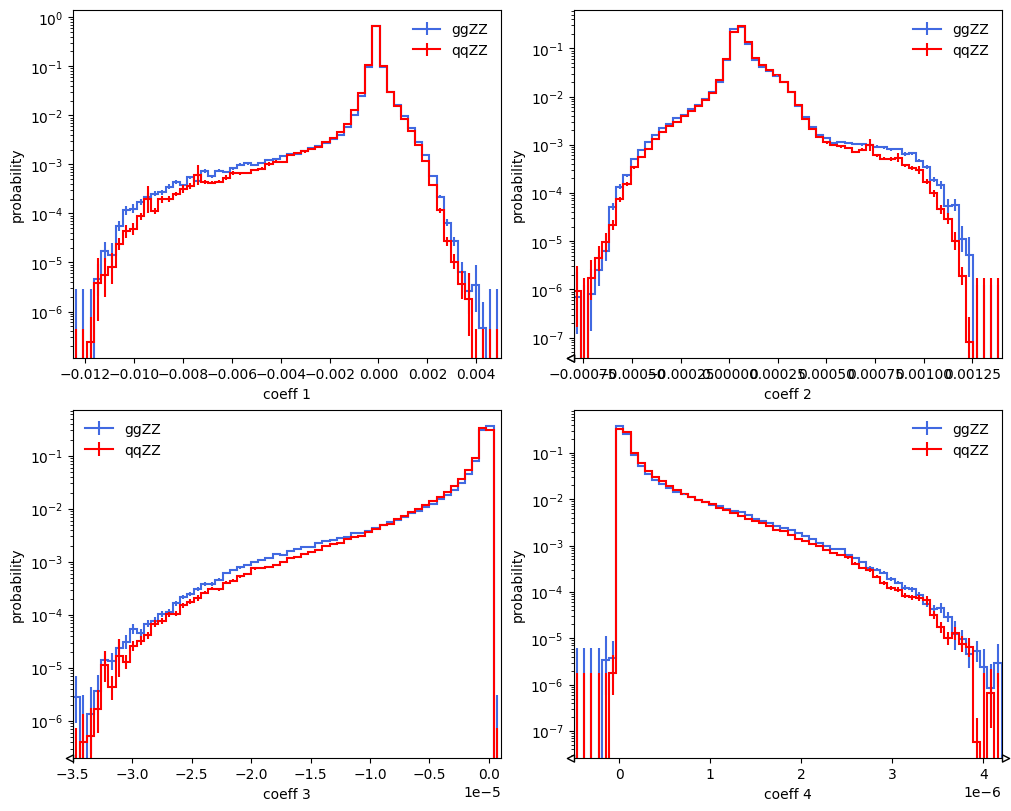

In [27]:
bins = 60

fig, axes = plt.subplots(2,2, figsize=(10,8), layout='constrained')


coeffs_tuple = (coeffs_pred[:SAMPLE_SIZE//2], coeffs_pred[SAMPLE_SIZE//2:])
probs_tuple = (events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities, events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities)

compare_hists_RP(0, axes[0,0], coeffs_tuple, probs_tuple, [-1.25e-2, 5e-3], bins)
compare_hists_RP(1, axes[0,1], coeffs_tuple, probs_tuple, [-8e-4, 1.4e-3], bins)
compare_hists_RP(2, axes[1,0], coeffs_tuple, probs_tuple, [-3.5e-5, 1e-6], bins)
compare_hists_RP(3, axes[1,1], coeffs_tuple, probs_tuple, [-5e-7, 4.2e-6], bins)

plt.show()

In [28]:
c6_values = np.linspace(*C6_LINSPACE)

In [29]:
def f(c6_values, coeffs):
    coefficients = np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)
    c6_matrix = np.vander(c6_values, coefficients.shape[1], increasing=True).T
    return np.dot(coefficients, c6_matrix).T

In [30]:
sigma_ggZZ_BSM = np.sum(ggZZ_wt_SM[np.newaxis,:] * f(c6_values, coeffs_pred[:SAMPLE_SIZE//2]), axis=1)
# This works because the order of events in events_ggZZ_processed and events_final is the same (for the first SAMPLE_SIZE//2 events)

In [46]:
# Comment out the sigma_qqZZ terms if performing on ggZZ only

full_SM_xs = sigma_ggZZ + sigma_qqZZ

full_BSM_xs = sigma_ggZZ_BSM + sigma_qqZZ 

nu_SM = full_SM_xs * luminosity
nu = full_BSM_xs * luminosity

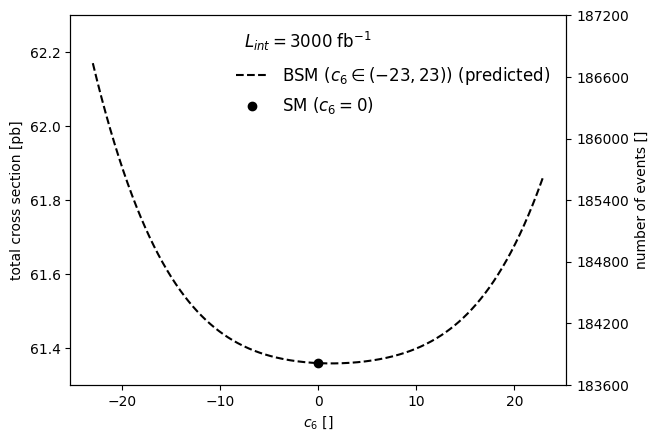

In [47]:
plt.plot(c6_values, full_BSM_xs, color='black', linestyle='--', zorder=1, label=f'BSM ($c_6 \in {C6_LINSPACE[0], C6_LINSPACE[1]}$) (predicted)')
#plt.plot(c6_values, sigma_ggZZ*np.sum(f(c6_values, coeffs_pred_ggZZ), axis=1)/GGZZ_INF_SIZE + sigma_qqZZ, color='royalblue', zorder=1, label='BSM ($c_6 \in [-20,20]$) (ROLYPOLY)')
plt.scatter(0, full_SM_xs, color='k', marker='o', zorder=2, label='SM ($c_6=0$)')
#plt.hlines(sigma_data, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], color='royalblue', linestyle='-', label='data')

ax1 = plt.gca()
ax1.set_ylim(ax1.get_yticks()[0],ax1.get_yticks()[-1])
#ax1.set_ylabel('$\sigma_{qqZZ} + \sigma_{ggZZ}$ [pb]')
ax1.set_ylabel('total cross section [pb]')

ax2 = ax1.twinx()

y_ticks_number = np.array(ax1.get_yticks())*luminosity

ax2.set_yticks(y_ticks_number)
ax2.set_ylim(y_ticks_number[0], y_ticks_number[-1])
ax2.set_ylabel('number of events []')


ax1.text(0.35,0.96,f'$L_{{int}} = {luminosity}$ fb$^{{-1}}$', transform=ax1.transAxes, fontsize=12, verticalalignment='top')
ax1.legend(frameon=False, loc=(0.32, 0.71), fontsize=12)
ax1.set_xlabel('$c_6$ []')

plt.show()

In [48]:
print(f'XS minimum at c6={c6_values[np.argmin(sigma_ggZZ_BSM)]:0.2f}')

XS minimum at c6=1.33


In [130]:
N_data = sigma_data*luminosity

# Poisson term
t_1 = - 2 * N_data * (np.log(nu) - np.log(nu_SM)) + 2 * (nu - nu_SM) 

In [35]:
# true ratios for ggZZ only
p_num = (c6_weights[:SAMPLE_SIZE]/np.sum(c6_weights[:SAMPLE_SIZE], axis=0))
p_den = (c6_weights[:SAMPLE_SIZE,c6_zero_index]/np.sum(c6_weights[:SAMPLE_SIZE,c6_zero_index], axis=0))[:,np.newaxis]

p_ratio_truth_ggZZ = p_num / p_den

In [36]:
#t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] + np.log(p_ratio_truth_ggZZ.T), axis=1)

In [37]:
#p_ratio = sigma_ggZZ/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)

In [131]:
p_ratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)/(1 + sigma_qqZZ/sigma_ggZZ * r)

In [132]:
rescaling_factor = np.sum(p_ratio * true_probs[c6_zero_index,:], axis=1)

p_ratio_fixed = p_ratio/rescaling_factor[:,np.newaxis]

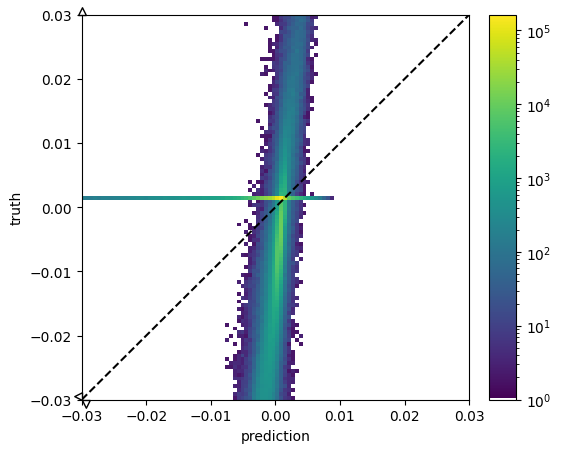

In [52]:
BINS=100

c6_val = -10
c6_val_index = np.where(np.linspace(*C6_LINSPACE) == c6_val)[0][0]

bounds = {-20: [-2e-1,5e-2],
          -10: [-3e-2,3e-2],
          -1:  [-3e-3,1e-3],
          0:   [-1e-10,1e-10],
          1:   [-5e-4,5e-4],
          10:  [-8e-3,8e-3],}[c6_val]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name=f'prediction'),
    hist.axis.Regular(BINS, *bounds, name='truth')
)

h_calibration_val.fill(-np.log(p_ratio)[c6_val_index,:], -np.log(true_probs[c6_val_index,:]/true_probs[c6_zero_index,:]))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=colors.LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

#plt.text(10,10,f'c6={c6_val}')

plt.show()

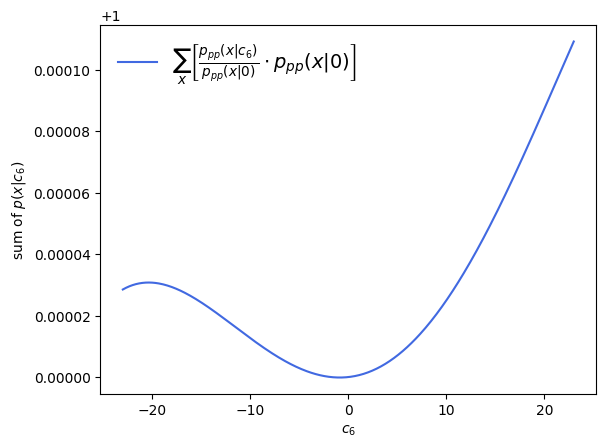

In [148]:
plt.plot(c6_values, rescaling_factor, color='royalblue', label='$\sum_{x}\left[\\frac{p_{pp}(x|c_6)}{p_{pp}(x|0)}\cdot p_{pp}(x|0)\\right]$')
plt.legend(frameon=False, fontsize=14)

plt.xlabel('$c_6$')
plt.ylabel('sum of $p(x|c_6)$')

plt.show()

In [133]:
# Used for ggZZ + qqZZ
#p_ratio = sigma_ggZZ/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)

t_3 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(p_ratio_fixed), axis=1)

In [ ]:
# Used for ggZZ only
t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(sigma_ggZZ/sigma_ggZZ_BSM[:,np.newaxis] * f(c6_values, coeffs_pred)), axis=1)

In [134]:
t = t_1 + t_3

In [135]:
t_min = c6_values[np.argmin(t)]

In [147]:
# Print top ten lowest values
print(c6_values[np.argsort(t)[:10]])
print(t[np.argsort(t)[:10]])

[-0.55555556 -0.44444444 -0.66666667 -0.33333333 -0.77777778 -0.22222222
 -0.88888889 -0.11111111 -1.          0.        ]
[-5.87973201e-04 -5.65624266e-04 -5.53644935e-04 -4.91282248e-04
 -4.57750083e-04 -3.69437776e-04 -2.95165202e-04 -2.04302196e-04
 -6.05988266e-05 -1.80513937e-08]


In [139]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))
ci_2 = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+4)))[:2]], 2))

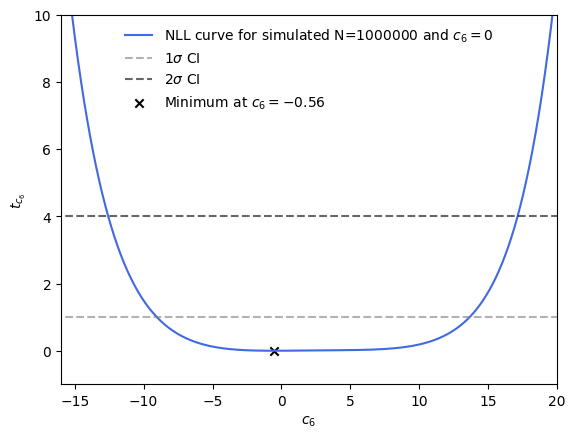

In [145]:
plt.plot(c6_values, t, color='royalblue', label=f'NLL curve for simulated N={SAMPLE_SIZE} and $c_6 = {C6_VAL_DATA}$')
plt.hlines(np.min(t)+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='grey', alpha=0.6, label=f'$1\sigma$ CI')# [{ci[0]},{ci[1]}]')
plt.hlines(np.min(t)+4, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$2\sigma$ CI')# [{ci_2[0]},{ci_2[1]}]')
plt.scatter(t_min, np.min(t), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

plt.xlabel('$c_6$')
plt.ylabel('$t_{c_6}$')
plt.ylim(-1,10)
plt.xlim(-16,20)
#plt.yscale('log')

plt.legend(frameon=False)
plt.show()